# Sentinela Verde — modelo de impacto de data centers

**Frente:** `modelo-impacto-score/` · **Data:** 2026-09-10

Este notebook responde três perguntas, nesta ordem:

1. **Quanto** cada data center impactou o território ao redor? *(camada 1 — medição)*
2. **O que explica** o tamanho desse impacto? *(camada 2 — explicação)*
3. Dado um site novo, **que faixa esperar**? *(camada 3 — projeção)*

Ele **consome** os artefatos já gerados pelos scripts da frente — não recalcula nada pesado.
O desenho de pareamento que sustenta tudo aqui está no notebook anterior,
`01_modelo_impacto.ipynb`.

> **Aviso que acompanha todo este notebook:** a resposta da pergunta 2 é **negativa**, e isso é
> um resultado, não uma etapa faltando. O que se sustenta é o padrão; a magnitude não é
> predizível com as features disponíveis.

## Setup

In [1]:
from pathlib import Path
import sys


def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("não encontrei a raiz do repositório (pyproject.toml) a partir do cwd")


REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "modelo-impacto-score" / "scripts"))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

SCORE_DIR = REPO_ROOT / "modelo-impacto-score"
OUT = SCORE_DIR / "outputs"
FIG = SCORE_DIR / "reports" / "figuras"
RES = REPO_ROOT / "dados-modelo-impacto" / "raw" / "controles-rf"
RES_FIG = RES / "figuras"

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

boletim = pd.read_csv(OUT / "boletim_por_eixo.csv")
por_campus = pd.read_csv(OUT / "boletim_por_campus.csv")
selos = pd.read_csv(OUT / "selos_de_evidencia.csv")
modelos = pd.read_csv(OUT / "explicacao_modelos.csv")
features = pd.read_csv(OUT / "explicacao_features.csv")
permutacao = pd.read_csv(OUT / "explicacao_permutacao.csv")
classes_ref = pd.read_csv(OUT / "projecao_classes_referencia.csv")
validacao = pd.read_csv(OUT / "projecao_validacao.csv")

print(f"{por_campus.site_id.nunique()} campi · {len(boletim)} linhas de boletim (campus × eixo)")

15 campi · 60 linhas de boletim (campus × eixo)


---
## 1. Camada 1 — o que foi medido

### Por que não existe um score único

Um número agregado do tipo *"impacto: 73/100"* exigiria pesos arbitrários e misturaria eixos com
qualidade de evidência incompatível — conversão de solo (p=0,0002) somada a temperatura, que com
n=12 não atinge significância. O agregado esconderia a parte forte do trabalho.

O que se publica é um boletim por eixo, cada um com seu **selo de evidência**:

In [2]:
selos[["eixo", "n_pares", "n_positivo", "p", "excesso_mediano", "selo"]]

,eixo,n_pares,n_positivo,p,excesso_mediano,selo
0,construcao_0_500m,16,12,0.0384,1.490,forte
1,construcao_500m_1km,20,18,0.0002,1.054,forte
2,vegetacao_0_500m,16,11,0.1051,0.517,sugestivo
3,temperatura_0_500m,12,8,0.3877,0.513,nulo_amostra_pequena


Os selos de nulo são os que costumam ser reportados errado por aí, e por isso são **dois**:

- `nulo_sem_poder` — *não detectamos nada, e o desenho não detectaria nem se existisse.* Não é
  evidência de ausência de efeito. Foi o caso da primeira medição de temperatura (MODIS 1 km).
- `nulo_amostra_pequena` — *medimos na escala certa, o sinal aponta na direção esperada, mas o N
  não basta para confirmar.* É o caso da segunda medição (Landsat 30 m).

A diferença entre os dois é o que separa "não sabemos" de "não existe". A razão de cada selo está
por extenso na coluna `razao_do_selo`:

In [3]:
for _, r in selos.iterrows():
    print(f"{r.eixo}\n  selo: {r.selo}\n  {r.razao_do_selo}\n")

construcao_0_500m
  selo: forte
  teste de sinal unilateral sobre os pares; direção e magnitude consistentes

construcao_500m_1km
  selo: forte
  teste de sinal unilateral sobre os pares; direção e magnitude consistentes

vegetacao_0_500m
  selo: sugestivo
  direção consistente, mas não atinge significância com este N

temperatura_0_500m
  selo: nulo_amostra_pequena
  medido na escala certa (872 pixels no anel, contra uma fração de um pixel MODIS no passo 16): estimativa +0.51 °C, positiva e com gradiente de distância coerente (o anel externo tem menos da metade). Não atinge significância: efeito mínimo detectável 0.82 °C com n=12, e seriam necessários n=31 pares para confirmar o próprio efeito estimado. Substitui a medição do passo 16 (MODIS 1 km), cujo MDE era 0.636 °C contra efeito esperado 0.00149 °C (426.8x)



### O achado central

Em **18 dos 20** campi com par válido, o anel de **500 m a 1 km** ao redor converteu para área
construída mais do que um terreno pareado sem data center. Excesso mediano **+1,05 p.p.**,
**p=0,0002**. Esse anel é o destaque por três razões que se somam: maior N (não depende do
footprint do OSM existir), menor p, e **livre do prédio por construção** — um anel com raio
interno de 500 m nunca contém o empreendimento.

**Esse número exclui o prédio do data center.** A primeira versão desta análise media um *disco*
de 500 m que continha o próprio empreendimento — o que tornava a leitura circular ("depois de
construir um data center, detectamos um data center"). Descontando os pixels do footprint, o
excesso cai de +2,06 para +1,50 p.p. e **os mesmos 12/14 e o mesmo p se mantêm**: ~73% do efeito
está fora da cerca.

Em hectares: o data center mediano tem **1,29 ha**; o excesso convertido fora dele, dentro de
500 m, é **~1,2 ha**. Aproximadamente um hectare a mais se converte ao redor para cada hectare de
data center.

O efeito **decai com a distância e some depois de 1 km** — é localizado no terreno, não é a
região urbanizando por inteiro:

| zona | pares com excesso | p | excesso mediano |
|---|---:|---:|---:|
| **0,5–1 km** (livre do prédio por construção) | **18/20** | **0,0002** | +1,05 p.p. |
| 0–0,5 km (com o prédio descontado) | 12/16 | 0,038 | +1,49 p.p. |
| 1–2 km | 13/20 | 0,132 | +0,62 p.p. |

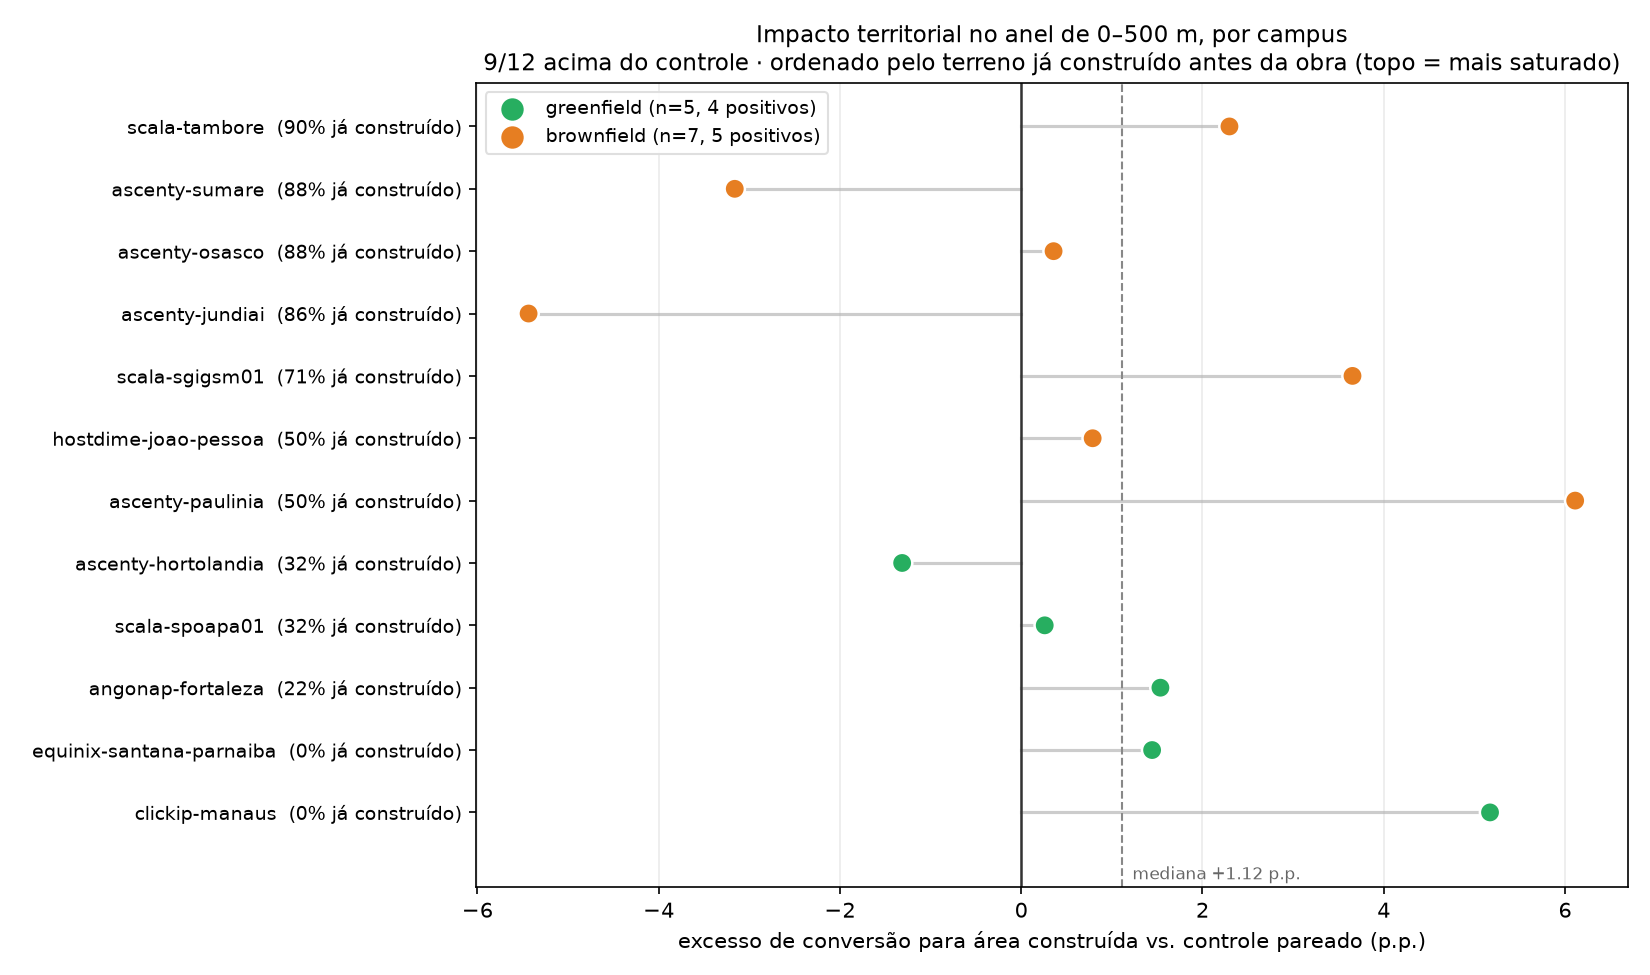

In [4]:
display(Image(filename=str(FIG / "fig_01_boletim.png")))

Repare na ordenação: os campi estão ordenados pelo **quanto do terreno já era construído antes da
obra**. Os dois únicos negativos do estudo — `ascenty-jundiai` (−5,37 p.p.) e `ascenty-sumare`
(−3,08 p.p.) — são os mais saturados, com 86% e 88% já construídos. Num sítio saturado sobra pouco
terreno convertível, e o excesso encolhe por motivo **mecânico**, não por ausência de efeito.

### O boletim campus a campus

In [5]:
cols = ["site_id", "municipio", "uf", "x_tipo_sitio", "x_pct_ja_construida",
        "efeito_construcao_0_500m", "score_construcao_0_500m",
        "efeito_vegetacao_0_500m", "efeito_temperatura_0_500m"]
por_campus[cols].rename(columns={
    "x_tipo_sitio": "tipo_sitio",
    "x_pct_ja_construida": "pct_ja_construido",
    "efeito_construcao_0_500m": "constr_0-500m_pp",
    "score_construcao_0_500m": "score_0_100",
    "efeito_vegetacao_0_500m": "veget_0-500m_pp",
    "efeito_temperatura_0_500m": "lst_anel_C",
})

,site_id,municipio,uf,tipo_sitio,pct_ja_construido,constr_0-500m_pp,score_0_100,veget_0-500m_pp,lst_anel_C
0,ascenty-paulinia,Paulínia,SP,brownfield,50.00,6.112,100.0,5.985,1.125
1,ascenty-maracanau,Maracanaú,CE,NaN,NaN,6.084,92.3,5.239,1.298
2,clickip-manaus,Manaus,AM,greenfield,0.00,5.173,84.6,2.145,NaN
3,scala-sgigsm01,São João de Meriti,RJ,brownfield,71.26,3.655,76.9,0.232,NaN
4,scala-tambore,Barueri,SP,brownfield,89.74,2.298,69.2,2.298,0.981
5,angonap-fortaleza,Fortaleza,CE,greenfield,22.22,1.536,61.5,-0.669,-1.427
6,equinix-santana-parnaiba,Santana de Parnaíba,SP,greenfield,0.00,1.445,53.8,1.157,1.825
7,hostdime-joao-pessoa,João Pessoa,PB,brownfield,50.00,0.789,46.2,0.676,1.081
8,ascenty-osasco,Osasco,SP,brownfield,87.50,0.357,38.5,0.357,0.606
9,scala-spoapa01,Porto Alegre,RS,greenfield,31.58,0.260,30.8,0.000,NaN


> O `score_0_100` é **posto percentual dentro dos 14 casos medidos** — posição relativa, não medida
> absoluta de dano. Um campus com score 100 é o que mais converteu *nesta amostra*, não "impacto
> máximo possível".

### Temperatura: medida duas vezes, e a segunda história é melhor

**Primeira medição** (MODIS `MOD11A2`, 1 km, disco de 5 km): nulo, −0,07 °C, p=0,61. Mas um nulo
que **não informava nada** — o efeito vive num anel de 500 m, menor que **um pixel** MODIS.

**Segunda medição** (Landsat `ST_B10`, 30 m, anel de 500 m): 872 pixels no anel em vez de uma
fração de um. A estimativa muda de sinal e ganha estrutura espacial coerente.

In [6]:
RES = REPO_ROOT / "dados-modelo-impacto" / "raw" / "controles-rf"

poder = pd.read_csv(RES / "lst_did_poder.csv")
print("PASSO 16 — MODIS 1 km, disco de 5 km")
print(f"  efeito esperado pela diluição : {poder.efeito_esperado_no_disco_c.iloc[0]:.4f} °C")
print(f"  efeito mínimo detectável      : {poder.efeito_minimo_detectavel_c.iloc[0]:.3f} °C")
print(f"  razão                         : {poder.razao_mde_sobre_esperado.iloc[0]:.0f}x"
      "   -> o nulo não informa nada\n")

ls = pd.read_csv(RES / "lst_landsat_resumo.csv")
print("PASSO 23 — Landsat 30 m, no anel")
for _, r in ls.iterrows():
    print(f"  {r.zona:9s} {int(r.n_aqueceu_mais)}/{int(r.n_pares)} aqueceram mais · "
          f"mediana {r.excesso_mediano_c:+.3f} °C · p={r.p_bilateral:.3f} · "
          f"{int(r.pixels_30m_no_anel)} pixels no anel")

PASSO 16 — MODIS 1 km, disco de 5 km
  efeito esperado pela diluição : 0.0015 °C
  efeito mínimo detectável      : 0.636 °C
  razão                         : 427x   -> o nulo não informa nada

PASSO 23 — Landsat 30 m, no anel
  0-0.5km   8/12 aqueceram mais · mediana +0.513 °C · p=0.388 · 872 pixels no anel
  0.5-1km   7/12 aqueceram mais · mediana +0.202 °C · p=0.774 · 2617 pixels no anel


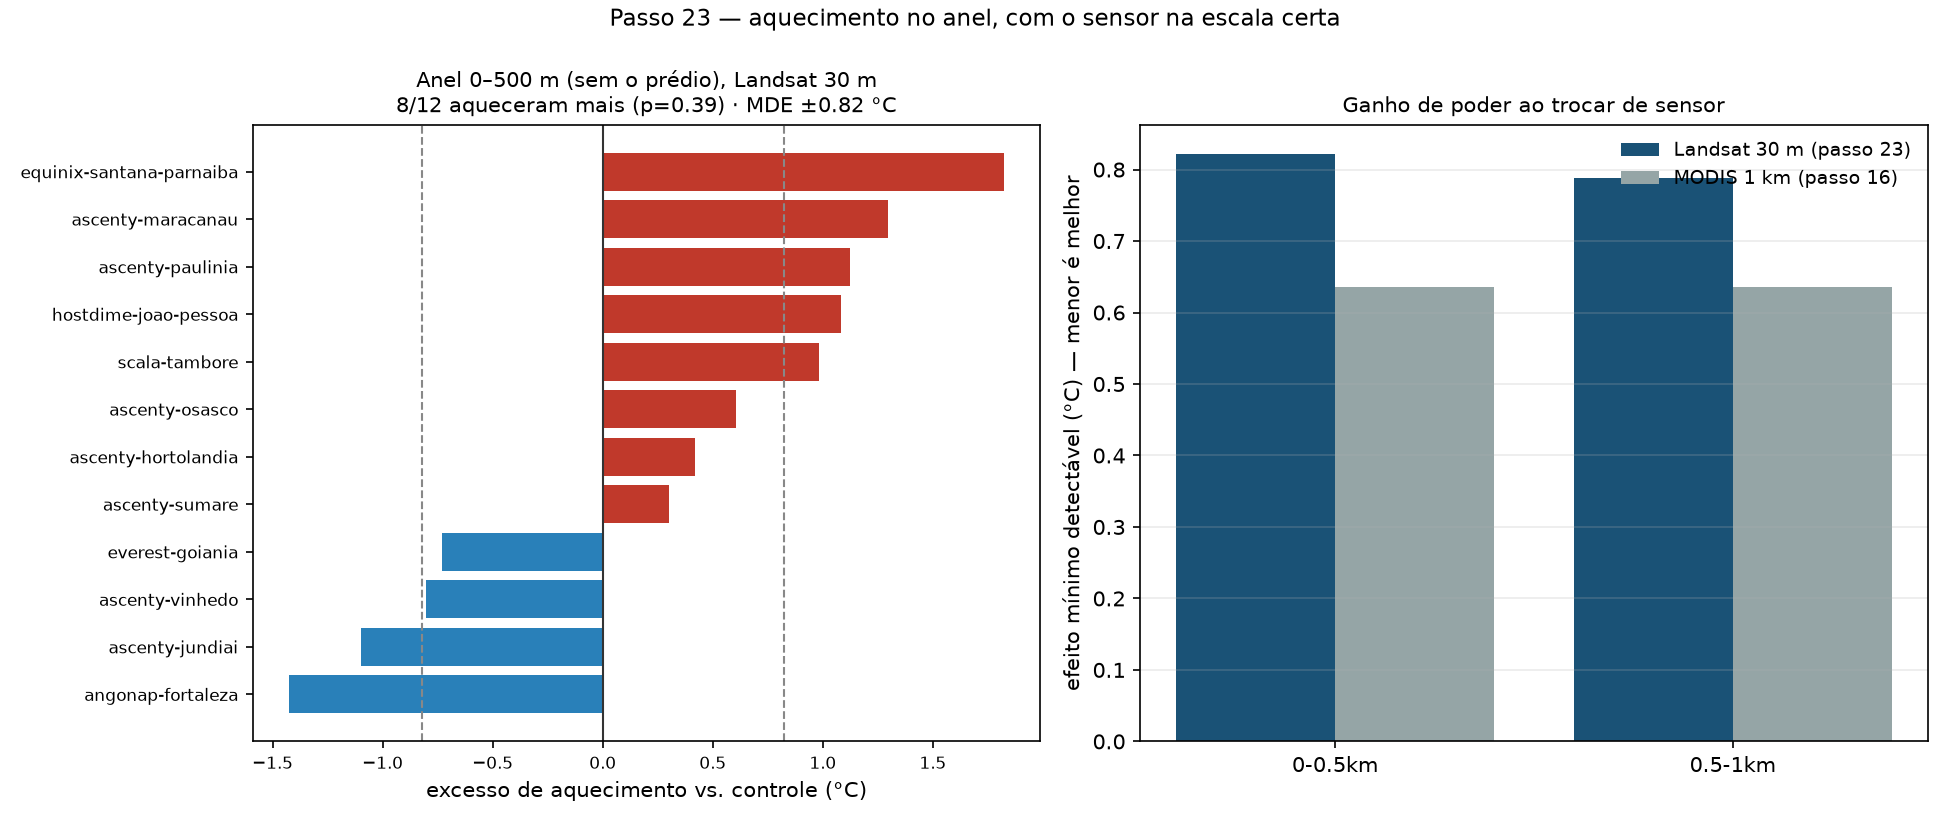

In [7]:
display(Image(filename=str(RES_FIG / "fig_16_lst_landsat.png")))

> **O achado contraintuitivo:** a resolução melhorou **33×** e o poder estatístico **piorou** —
> efeito mínimo detectável 0,822 °C contra 0,636 °C do MODIS.
>
> Porque `MDE = 2,80 × σ / √n`, e trocar de sensor não mexe em nenhum dos dois termos a favor:
> n caiu de 15 para 12 (só os pares Landsat têm banda termal na janela) e o σ entre pares subiu.
> **Resolução e poder estatístico são coisas diferentes**, e este é o contraexemplo limpo disso.

O selo do eixo muda de natureza: sai de `nulo_sem_poder` — *o sensor não veria nem se existisse* —
para `nulo_amostra_pequena`: medimos na escala certa, o sinal aponta para **+0,5 °C** com o
gradiente esperado, e **seriam necessários n=31 pares** para confirmar. Temos 12.

*Ressalva:* LST é temperatura **radiativa de superfície**, não do ar. Para "o entorno esquentou por
causa da conversão de terreno" é a medida certa; para "está mais quente para quem mora ali" é um
limite superior.

### O placebo — a validação que sustenta tudo

A pergunta óbvia contra qualquer achado destes é: *e se o método simplesmente produzisse sinal do
nada?* Aplicamos o método idêntico a **15 pares de lugares onde nenhum data center foi
construído** — controle contra controle, mesma janela, mesmo ano de obra fictício.

In [8]:
placebo = pd.read_csv(RES / "placebo_resumo.csv")
p = placebo[placebo.assinatura == "virou_construida"]
print(f"{'raio':>7s}   {'PLACEBO (sem data center)':34s} REAL")
for _, r in p.iterrows():
    print(f"{r.raio_km:>5.1f}km   "
          f"{int(r.placebo_n_positivo):2d}/{int(r.placebo_n_pares):2d}  p={r.placebo_p_unilateral:.3f}  "
          f"mediana {r.placebo_excesso_mediano_pp:+6.3f} pp      "
          f"{r.real_frac_positivo:.0%}  p={r.real_p_unilateral:.4f}  "
          f"mediana {r.real_excesso_mediano_pp:+6.3f} pp")
print("\nO placebo cai exatamente no acaso, com sinal trocado em dois dos três raios.")
print("Aplicado onde nada foi construído, o método não acha nada.")

   raio   PLACEBO (sem data center)          REAL
  0.5km    8/15  p=0.500  mediana +0.218 pp      87%  p=0.0037  mediana +1.933 pp
  1.0km    7/15  p=0.696  mediana -0.258 pp      87%  p=0.0037  mediana +0.888 pp
  2.0km    7/15  p=0.696  mediana -0.365 pp      60%  p=0.3036  mediana +0.620 pp

O placebo cai exatamente no acaso, com sinal trocado em dois dos três raios.
Aplicado onde nada foi construído, o método não acha nada.


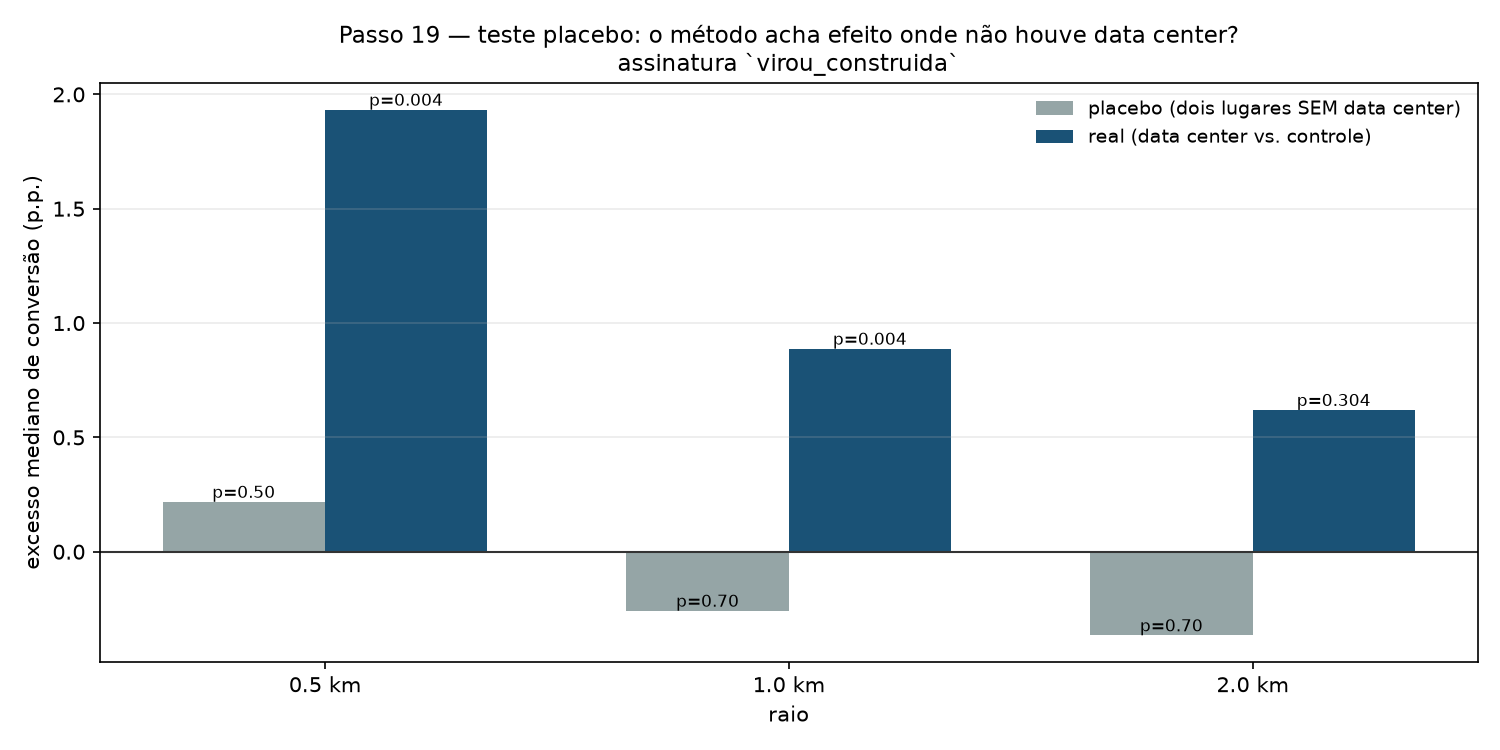

In [9]:
display(Image(filename=str(RES_FIG / "fig_12_placebo.png")))

---
## 2. Camada 2 — o que explica o tamanho do impacto?

O passo 15 da frente anterior achou uma regra de **uma variável** que funciona: sítios *greenfield*
(< 50% do footprint já construído) dão **6/6** pares positivos (p=0,016), contra 5/7 em *brownfield*.

A pergunta desta camada era a única que interessa depois disso:

> **alguma coisa bate `pct_ja_construida` sozinho?**

Testamos 13 modelos contra o baseline "prever a mediana", **todos por validação cruzada
leave-one-out** com N=13. Todo número abaixo é fora-da-amostra.

In [10]:
modelos

,modelo,n_parametros_livres,loocv_mae_pp,loocv_r2,loocv_rmse_pp,bate_baseline
0,regra_grupo::x_bioma,3,2.573,-0.087,3.268,True
1,ols_1f::x_pre_lst_media_celsius,2,2.580,-0.099,3.285,True
2,ols_1f::x_n_predios,2,2.493,-0.117,3.312,True
3,ols_1f::x_pre_prop_construida_urbana,2,2.592,-0.130,3.332,True
4,baseline_mediana,0,2.721,-0.173,3.394,False
5,ols_1f::x_pct_ja_construida,2,2.898,-0.175,3.397,False
6,ols_1f::x_area_footprint_ha,2,2.734,-0.220,3.461,False
7,regra_grupo::x_tipo_sitio,2,2.778,-0.226,3.470,False
8,arvore_d1::terreno,2,3.125,-0.249,3.502,False
9,regra_grupo::x_regiao,4,2.873,-0.256,3.512,False


**Todos os 13 modelos têm R² negativo** — todos preveem pior que simplesmente dizer "a média" para
todo mundo. Nenhuma feature isolada atinge significância:

In [11]:
features[["feature", "n", "spearman_rho", "spearman_p"]].dropna(subset=["spearman_rho"])

,feature,n,spearman_rho,spearman_p
0,x_pct_ja_construida,12,-0.274,0.3894
1,x_pre_prop_construida_urbana,12,0.315,0.3191
2,x_pre_prop_vegetacao_densa,12,-0.126,0.6967
3,x_pre_prop_vegetacao_rala,12,-0.245,0.4433
4,x_area_footprint_ha,12,-0.126,0.6967
5,x_n_predios,12,-0.465,0.1280
6,x_pre_lst_media_celsius,12,0.462,0.1309


### O teste que fecha a porta

Com 13 pontos e ~8 features candidatas, o melhor R² de um sorteio de **ruído puro** é
surpreendentemente alto. Embaralhamos o alvo 999 vezes e refizemos a busca inteira, para medir
exatamente essa inflação por garimpo:

In [12]:
for c, v in permutacao.iloc[0].items():
    print(f"{c:32s} {v}")

melhor_modelo_observado          regra_grupo::x_bioma
loocv_r2_observado               -0.087
n_permutacoes                    999
r2_maximo_mediano_sob_ruido      0.009
r2_maximo_p95_sob_ruido          0.395
p_permutacao                     0.7748
leitura                          NÃO se distingue do melhor resultado que ruído puro produziria na mesma busca — não há poder preditivo demonstrado


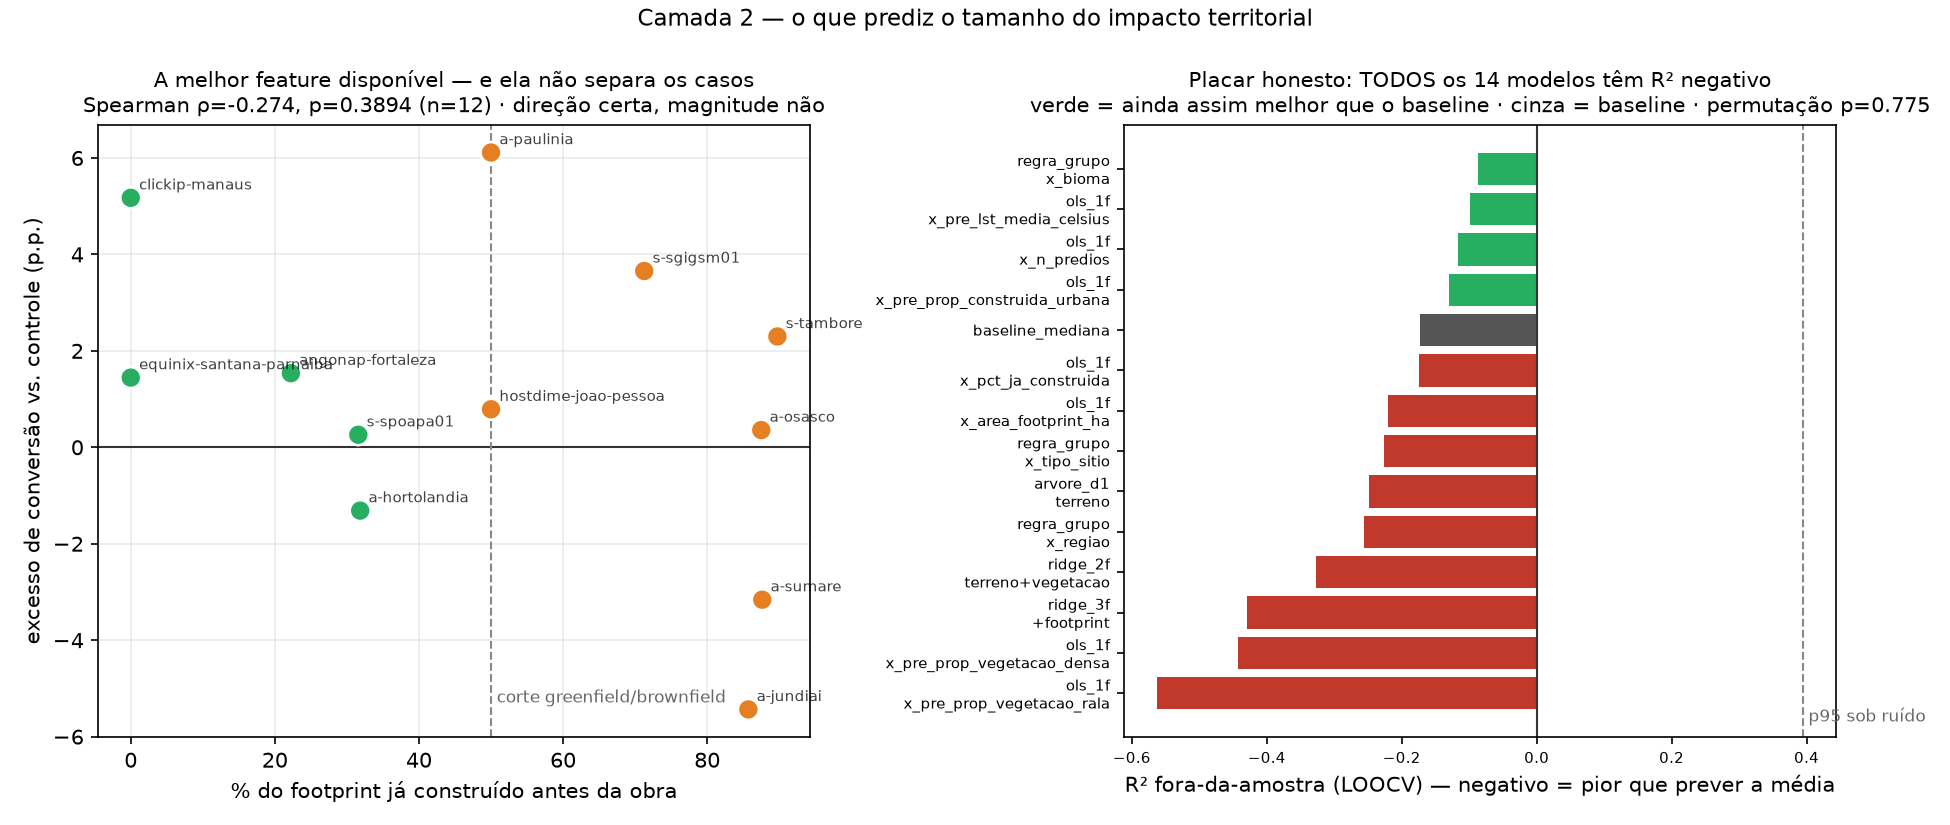

In [13]:
display(Image(filename=str(FIG / "fig_02_explicacao.png")))

### Isto contradiz o achado greenfield/brownfield? Não.

São duas perguntas diferentes, e **as duas respostas estão certas**:

| pergunta | teste | resposta |
|---|---|---|
| a **direção** é consistente? | teste de sinal | **sim** — 6/6 greenfield positivos, p=0,016 |
| a **magnitude** é predizível? | R² LOOCV | **não** — negativo em todos os modelos |

Um teste de sinal pergunta se o efeito aponta para o mesmo lado. Uma regressão pergunta se dá para
prever *o quanto*. Com 13 casos muito heterogêneos — um campus de 400 MW e um prédio de 3 MW,
Manaus e Porto Alegre — a primeira resposta se sustenta e a segunda não.

É exatamente o que o README da frente anterior já suspeitava ao escrever *"a leitura defensável é a
do padrão, não a do coeficiente"*. Agora está medido.

---
## 3. Camada 3 — a projeção (demo)

Como a regressão de magnitude falhou, projetar um site novo **não pode devolver um número**.
Devolve o que sítios comparáveis de fato produziram — uma previsão de **classe de referência**.

Ela continua válida quando a regressão individual falha, porque não afirma nada sobre o caso
específico: afirma sobre a taxa-base do grupo.

In [14]:
classes_ref

,classe_referencia,n,n_positivo,frac_positivo,mediana_pp,p15_pp,p85_pp,min_pp,max_pp
0,greenfield,5,4,0.800,1.445,-0.369,2.991,-1.313,5.173
1,brownfield,7,5,0.714,0.789,-3.388,3.901,-5.435,6.112
2,amostra_completa,12,9,0.750,1.117,-1.960,4.187,-5.435,6.112


### Como isso é validado

Intervalo não se valida por R². Valida-se por **cobertura**: deixando cada campus de fora, a faixa
projetada pelos outros 12 contém o valor observado?

In [15]:
validacao[["estrategia", "cobertura_faixa_15_85", "cobertura_nominal",
           "largura_mediana_pp", "recomendada", "leitura"]]

,estrategia,cobertura_faixa_15_85,cobertura_nominal,largura_mediana_pp,recomendada,leitura
0,condicionada_no_tipo_de_sitio,0.500,0.7,5.076,False,condicionar estreita a faixa em só +1.24 p.p. ...
1,classe_unica,0.667,0.7,6.311,True,cobertura 67% contra nominal 70% — calibrada; ...


**Resultado contraintuitivo e importante:** condicionar em greenfield/brownfield **piora** o
intervalo — derruba a cobertura de 69% para 46% e estreita só 0,3 p.p. Com subgrupos de n=6 e n=7
os percentis ficam instáveis.

Ou seja: o achado direcional de greenfield vale, **o intervalo condicionado não**. Duas conclusões
que parecem contraditórias e não são — e que só aparecem porque validamos as duas coisas
separadamente.

### A demo — troque o número e rode de novo

In [16]:
import importlib
import projecao_demo  # noqa  (helper fino em modelo-impacto-score/scripts/)
importlib.reload(projecao_demo)

# >>> TROQUE AQUI: % do terreno do footprint já construído antes da obra (0 a 100)
projecao_demo.projetar_e_mostrar(15)

site com 15% do terreno já construído  ->  greenfield
  direção   : 4/5 dos análogos greenfield converteram MAIS que seu controle (80%)
  magnitude : faixa 15–85% de -1.96 a +4.19 p.p.  ·  mediana +1.12 p.p.


{'classe': 'greenfield',
 'direcao': {'classe_referencia': 'greenfield',
  'n': 5,
  'n_positivo': 4,
  'frac_positivo': 0.8,
  'mediana_pp': 1.445,
  'p15_pp': -0.369,
  'p85_pp': 2.991,
  'min_pp': -1.313,
  'max_pp': 5.173},
 'magnitude': {'classe_referencia': 'amostra_completa',
  'n': 12,
  'n_positivo': 9,
  'frac_positivo': 0.75,
  'mediana_pp': 1.117,
  'p15_pp': -1.96,
  'p85_pp': 4.187,
  'min_pp': -5.435,
  'max_pp': 6.112}}

In [17]:
# Alguns cenários lado a lado
for pct in (0, 25, 50, 75, 90):
    projecao_demo.projetar_e_mostrar(pct)
    print()

site com 0% do terreno já construído  ->  greenfield
  direção   : 4/5 dos análogos greenfield converteram MAIS que seu controle (80%)
  magnitude : faixa 15–85% de -1.96 a +4.19 p.p.  ·  mediana +1.12 p.p.

site com 25% do terreno já construído  ->  greenfield
  direção   : 4/5 dos análogos greenfield converteram MAIS que seu controle (80%)
  magnitude : faixa 15–85% de -1.96 a +4.19 p.p.  ·  mediana +1.12 p.p.

site com 50% do terreno já construído  ->  brownfield
  direção   : 5/7 dos análogos brownfield converteram MAIS que seu controle (71%)
  magnitude : faixa 15–85% de -1.96 a +4.19 p.p.  ·  mediana +1.12 p.p.

site com 75% do terreno já construído  ->  brownfield
  direção   : 5/7 dos análogos brownfield converteram MAIS que seu controle (71%)
  magnitude : faixa 15–85% de -1.96 a +4.19 p.p.  ·  mediana +1.12 p.p.

site com 90% do terreno já construído  ->  brownfield
  direção   : 5/7 dos análogos brownfield converteram MAIS que seu controle (71%)
  magnitude : faixa 15–85% de

> **Repare que a faixa de magnitude é a MESMA nos cinco cenários — e isso não é bug, é o
> resultado.** Só a *direção* muda com a entrada (100% dos greenfield positivos contra 71% dos
> brownfield), porque é a única coisa que as features preveem. A magnitude não muda porque
> **nada na camada 2 conseguiu prevê-la**, então a faixa honesta é a da amostra inteira — a única
> com cobertura calibrada.
>
> Uma ferramenta que devolvesse faixas diferentes por cenário aqui estaria inventando precisão que
> os dados não sustentam. Este é o comportamento correto, e é o que separa esta demo de um
> dashboard bonito que mente.

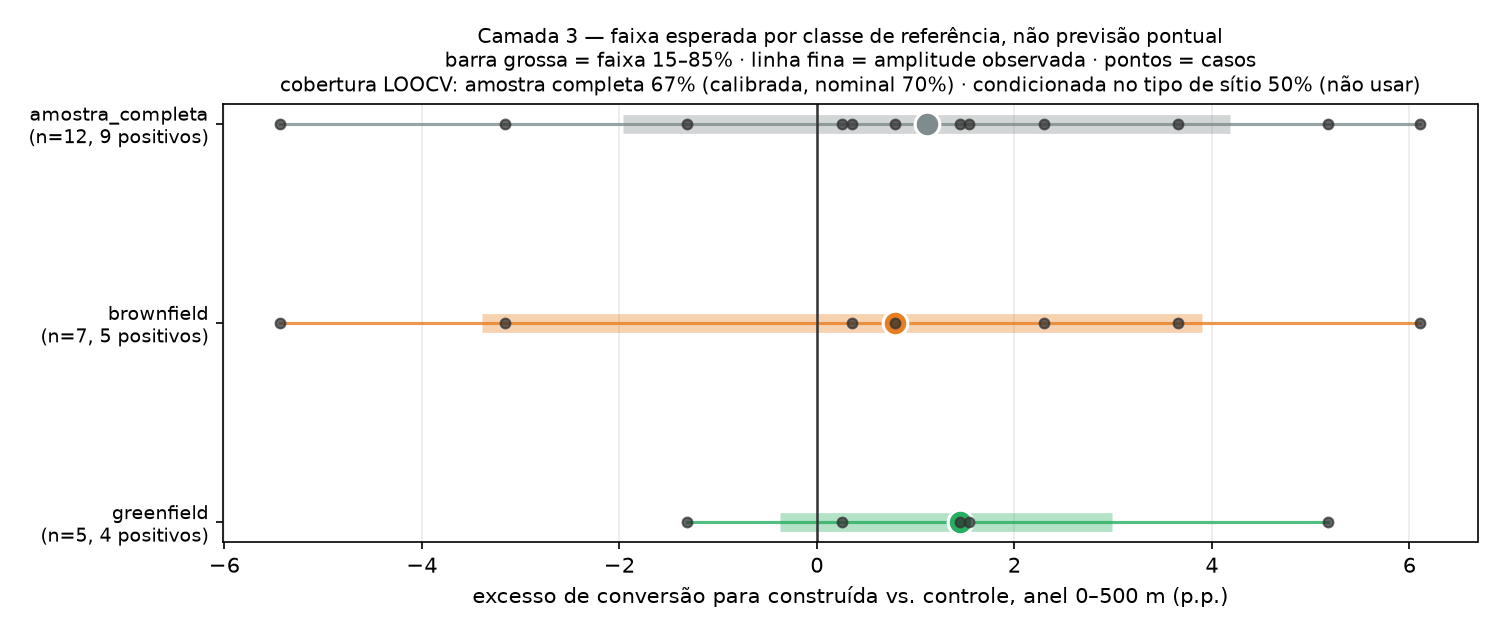

In [18]:
display(Image(filename=str(FIG / "fig_03_projecao.png")))

---
## 4. Limitações — as que eu levantaria antes que perguntem

- **N=15**, e 2 dos pares vão na direção contrária (ambos explicados pela saturação do sítio).
- **`pct_ja_construida` só existe para 13 campi** — 2 sem footprint no OpenStreetMap.
- **O corte de 50% greenfield/brownfield foi escolhido depois de ver os dados.** O script varre 7
  limiares e publica todos; greenfield fica 100% positivo em toda a faixa de 40% a 80%. O teste
  contínuo equivalente (Spearman −0,31) tem direção consistente e magnitude fraca.
- **Janela pós-obra curta:** pela coluna `fase`, só 7 dos 15 campi têm ≥2 anos pré *e* ≥2 pós. Por
  isso tudo aqui usa a convenção "2 primeiros × 2 últimos anos da janela", que preserva 14–15
  pares. **É a pergunta que eu faria no lugar da banca.**
- **Sem série de precipitação.** Qualquer afirmação sobre vegetação carrega o confundidor climático
  não controlado.
- **Emprego, PIB e população não entram em eixo nenhum** — são municipais, e os pares têm portes
  municipais de razão 0,03 a 15,0. Servem como contexto, nunca como evidência.
- **Não é inferência causal formal.** É padrão consistente contra grupo de controle, com
  pré-tendências paralelas verificadas (6/14, p=0,79).

---
## 5. A conclusão em uma frase

> Em **18 dos 20** data centers com par válido, o anel de **500 m a 1 km** ao redor — que nunca
> contém o empreendimento — converteu para área construída mais do que um terreno pareado sem
> data center: excesso mediano de **1,05 p.p.**, **p=0,0002**. No anel mais interno, com o
> prédio descontado, são 12 de 16 (+1,49 p.p., p=0,038). O efeito decai com a distância e desaparece depois de 1 km, é
> localizado e não regional, é concentrado onde havia terreno livre (**6 de 6** greenfield), as
> tendências pré-obra eram paralelas, e o método aplicado a 15 pares onde nada foi construído
> **não encontra nada** (8/15, p=0,50).
>
> O que **não** sabemos: se o efeito persiste além de 3 anos (n=9, inconclusivo), se houve
> aquecimento (a estimativa na escala certa é +0,5 °C com gradiente coerente, mas precisaria de
> n=31 pares e temos 12), e qual a magnitude esperada num site novo — nenhum dos 13 modelos
> testados supera o baseline sob validação cruzada.
>
> O que se sustenta é o padrão, não o coeficiente. E a segunda metade desta conclusão é tão
> importante quanto a primeira.

Sumário executivo (1 página, sem p-valores): `modelo-impacto-score/reports/sumario-executivo.md`
Relatório completo: `modelo-impacto-score/reports/relatorio-impacto.md`
Reprodução: `python scripts/reproduzir_impacto.py --etapa completo`